In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.cluster import KMeans

In [2]:
kmeans = KMeans()

In [3]:
dataset = pd.read_csv('Cleaned Mental Health Data.csv')

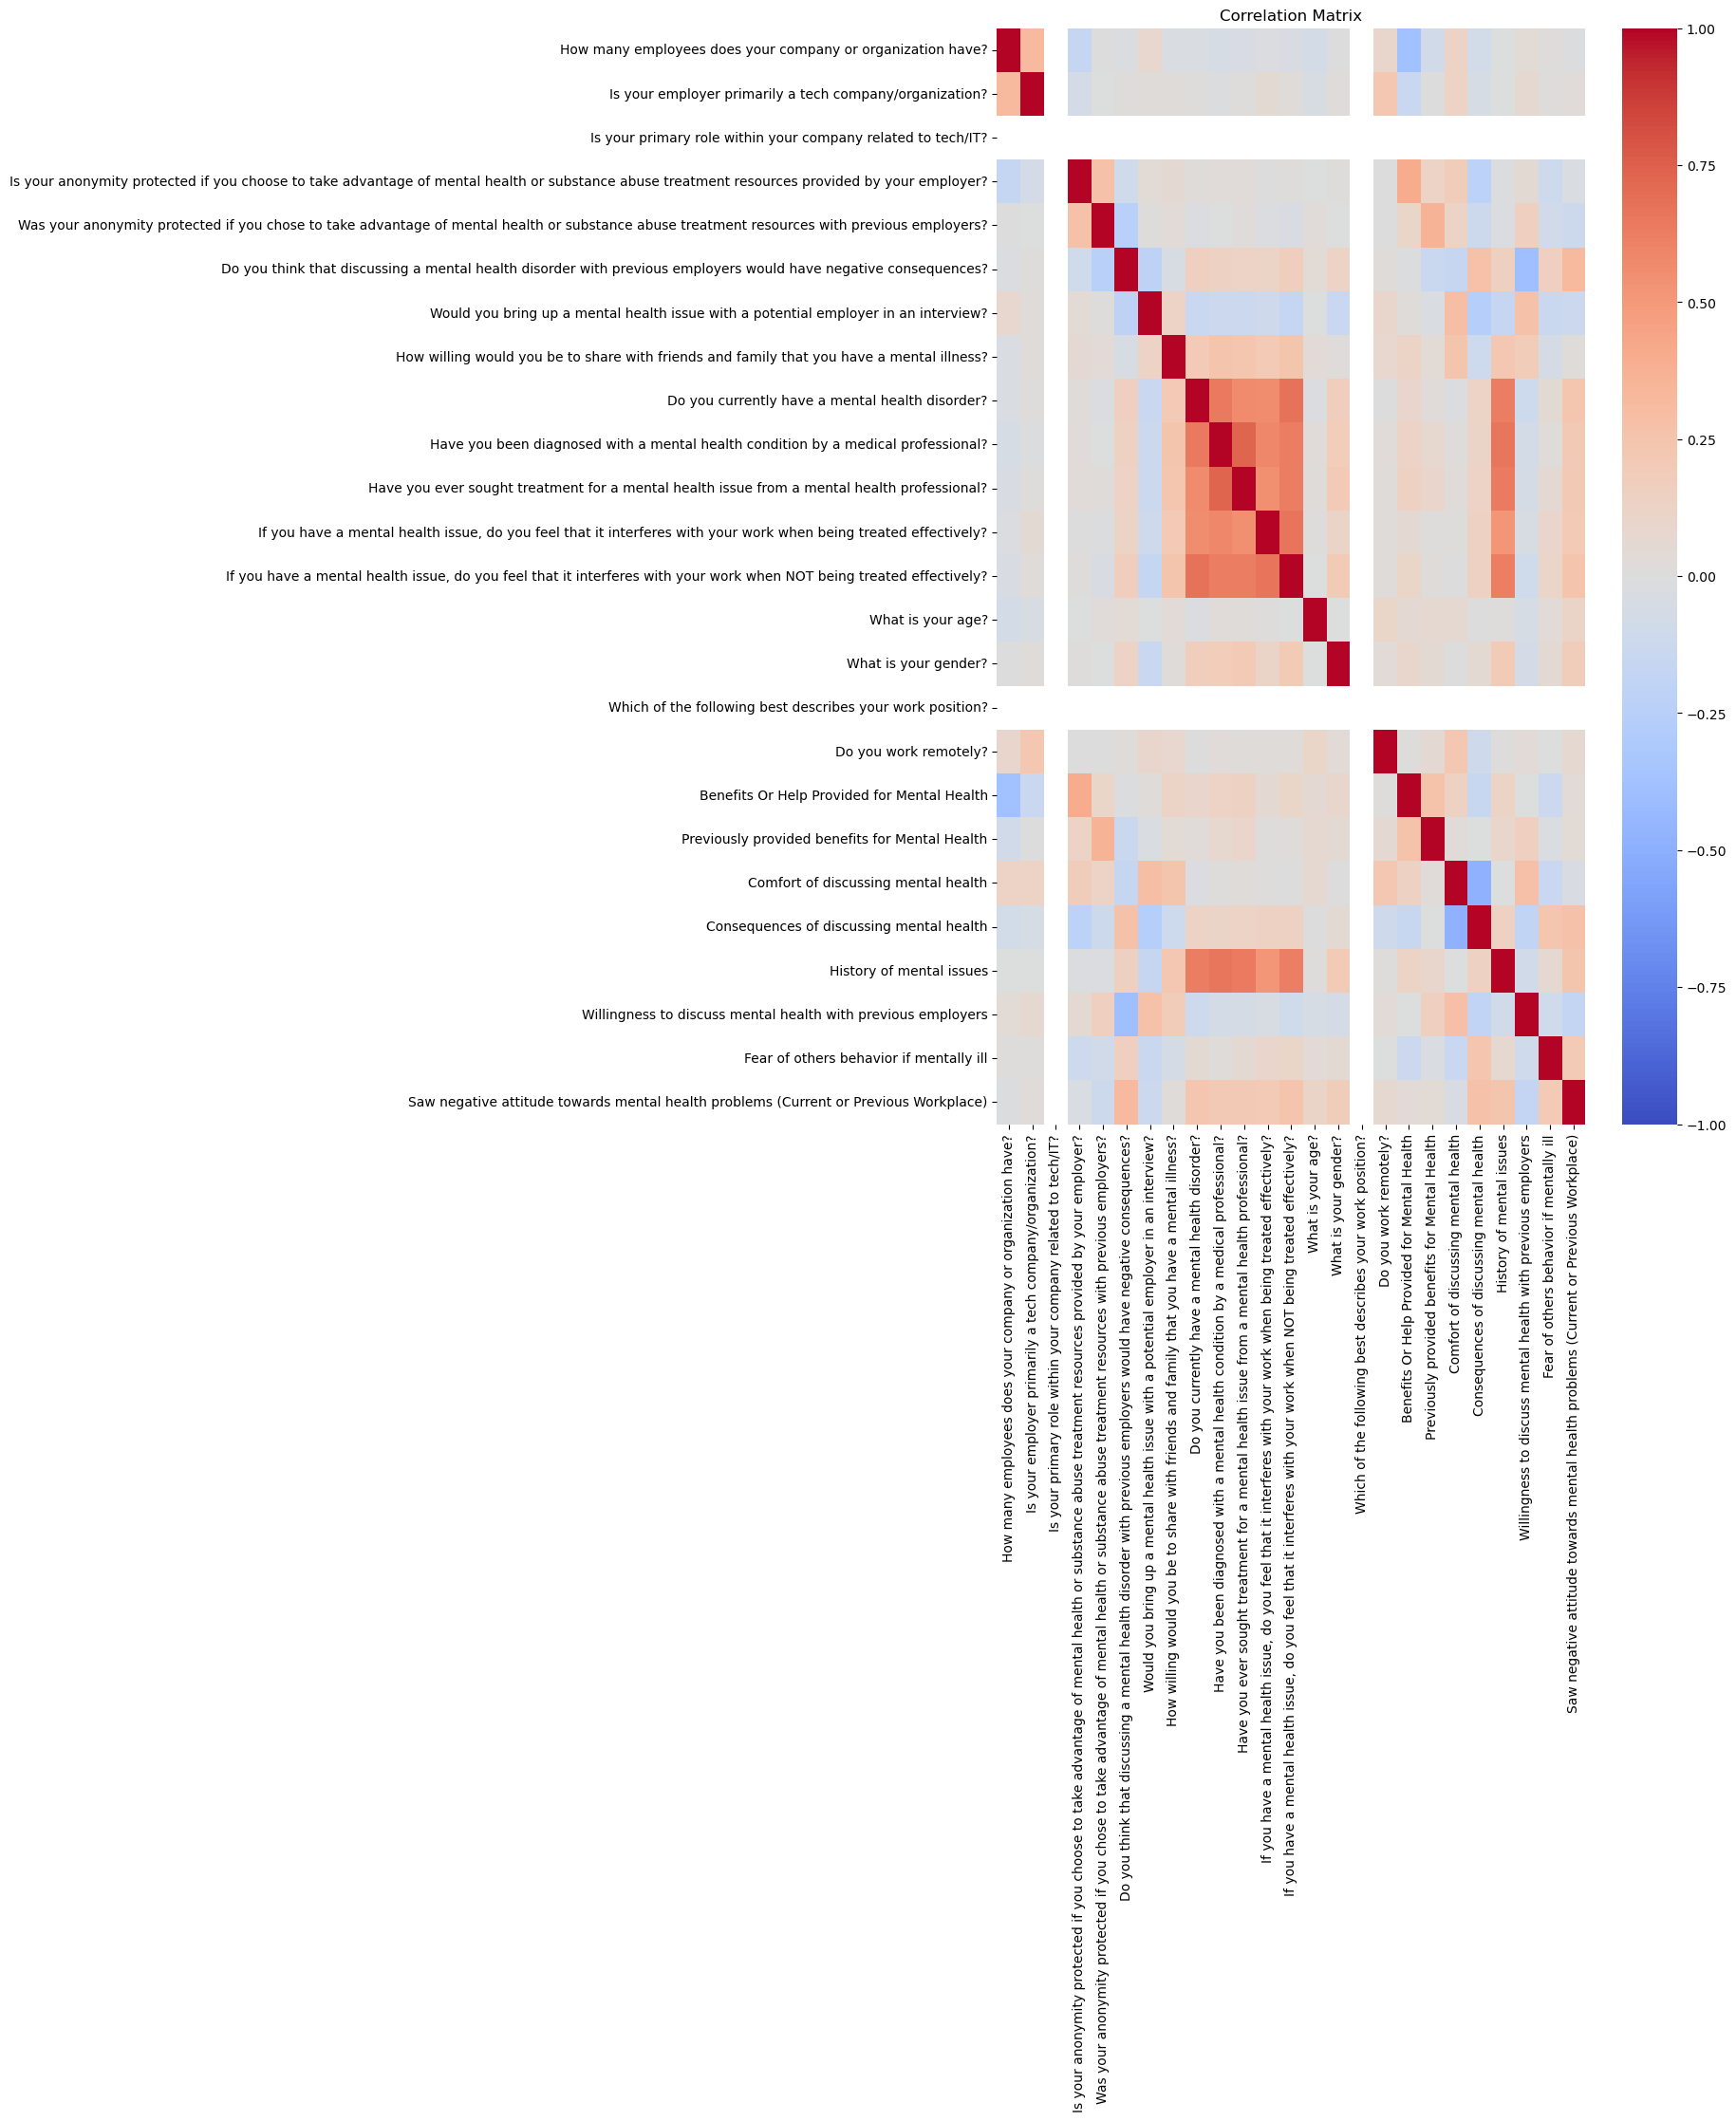

In [4]:
corr_mtrx = dataset.corr()
plt.figure(figsize= (10, 15))
sns.heatmap(corr_mtrx, annot= False, cmap= 'coolwarm', vmin= -1, vmax= 1 )
plt.title('Correlation Matrix')
plt.show()

In [1]:
corr_mtrx.unstack().sort_values(ascending=False).drop_duplicates()

NameError: name 'corr_mtrx' is not defined

In [ ]:

# 1. Fit K-Means (Assuming 2 clusters for this example)
kmeans = KMeans(n_clusters=2, random_state=42)
dataset['Cluster'] = kmeans.fit_predict(dataset)

# 2. Interpret the clusters by calculating the mean of each column
cluster_profiles = dataset.groupby('Cluster').mean()
cluster_profiles.T

Cluster,0,1
How many employees does your company or organization have?,3.208955,3.514226
Is your employer primarily a tech company/organization?,0.797441,0.838778
Is your primary role within your company related to tech/IT?,1.000000,1.000000
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,1.144989,1.169652
Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,1.055437,1.015806
Do you think that discussing a mental health disorder with previous employers would have negative consequences?,1.127932,1.051633
Would you bring up a mental health issue with a potential employer in an interview?,0.471215,0.458377
How willing would you be to share with friends and family that you have a mental illness?,1.053305,1.045311
Do you currently have a mental health disorder?,1.019190,1.036881
Have you been diagnosed with a mental health condition by a medical professional?,0.530917,0.485774


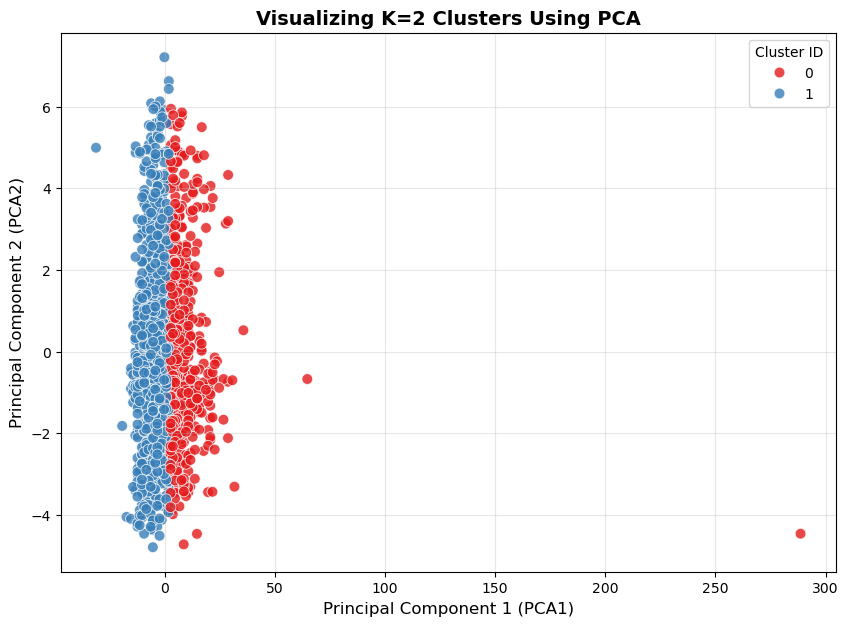

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# 1. Separate your features from the 'Cluster' column
# This prevents PCA from accidentally using the cluster labels to plot
features = dataset.drop(columns=["Cluster"], errors="ignore")

# 2. Compress the 25 columns into 2 dimensions
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(features)

# 3. Add the PCA coordinates back to your dataset for plotting
dataset["PCA1"] = pca_results[:, 0]
dataset["PCA2"] = pca_results[:, 1]

# 4. Plot the 2D Scatter Plot
plt.figure(figsize=(10, 7))

# 'hue' colors the dots by your 2 clusters
sns.scatterplot(
    data=dataset,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set1",  # High-contrast colors for 2 clusters
    s=60,
    alpha=0.8,
)

plt.title("Visualizing K=2 Clusters Using PCA", fontsize=14, weight="bold")
plt.xlabel("Principal Component 1 (PCA1)", fontsize=12)
plt.ylabel("Principal Component 2 (PCA2)", fontsize=12)
plt.legend(title="Cluster ID", loc="best")
plt.grid(True, alpha=0.3)
plt.show()

# 5. Clean up the dataset by removing the temporary PCA columns
dataset = dataset.drop(columns=["PCA1", "PCA2"])

In [16]:
from sklearn.metrics import silhouette_score
k_range = range(2, 15)
silhouette_scores =[]
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    cluster_labels = kmeans.fit_predict(dataset)

    # Calculate the average silhouette score for this K
    score = silhouette_score(dataset, cluster_labels)
    silhouette_scores.append(score)
    print(f"For K = {k}, the average Silhouette Score is: {score:.2f}")

For K = 2, the average Silhouette Score is: 0.41
For K = 3, the average Silhouette Score is: 0.31
For K = 4, the average Silhouette Score is: 0.29
For K = 5, the average Silhouette Score is: 0.22
For K = 6, the average Silhouette Score is: 0.20
For K = 7, the average Silhouette Score is: 0.19
For K = 8, the average Silhouette Score is: 0.16
For K = 9, the average Silhouette Score is: 0.15
For K = 10, the average Silhouette Score is: 0.14
For K = 11, the average Silhouette Score is: 0.13
For K = 12, the average Silhouette Score is: 0.13
For K = 13, the average Silhouette Score is: 0.12
For K = 14, the average Silhouette Score is: 0.12


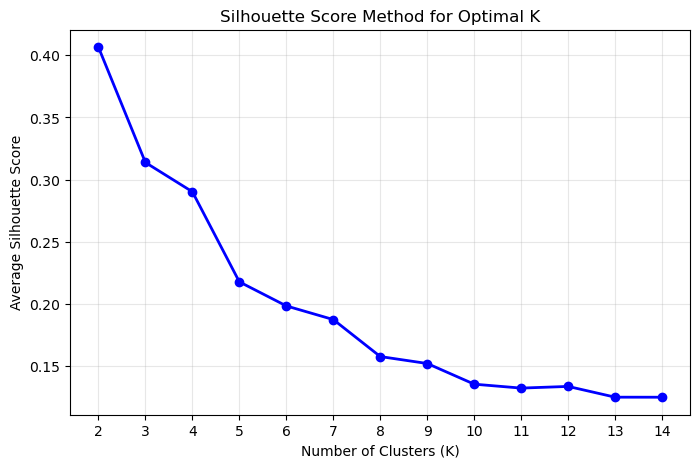

In [17]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', color='b', linewidth=2)
plt.title("Silhouette Score Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Average Silhouette Score")
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.show()

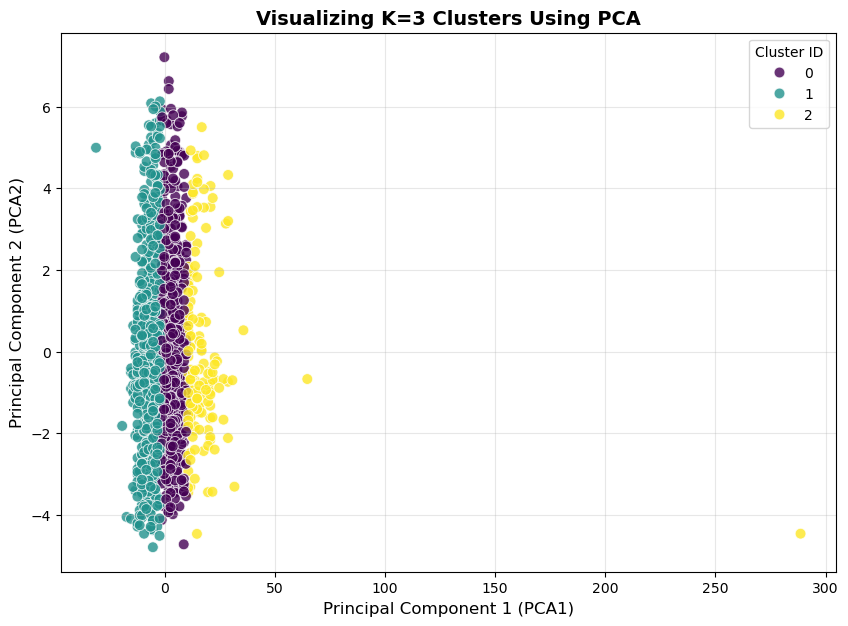

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Run K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
dataset['Cluster'] = kmeans.fit_predict(dataset.drop(columns=['Cluster'], errors='ignore'))

# 2. Separate features for PCA compression
features = dataset.drop(columns=['Cluster'], errors='ignore')

# 3. Compress the 25 columns into 2 dimensions
pca = PCA(n_components=2, random_state=42)
pca_results = pca.fit_transform(features)

dataset['PCA1'] = pca_results[:, 0]
dataset['PCA2'] = pca_results[:, 1]

# 4. Plot the 3D data onto a 2D Scatter Plot
plt.figure(figsize=(10, 7))

# 'palette=viridis' or 'Set1' works great for showing 3 distinct groups
sns.scatterplot(
    data=dataset,
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    palette='viridis', 
    s=60,
    alpha=0.8
)

plt.title("Visualizing K=3 Clusters Using PCA", fontsize=14, weight='bold')
plt.xlabel("Principal Component 1 (PCA1)", fontsize=12)
plt.ylabel("Principal Component 2 (PCA2)", fontsize=12)
plt.legend(title="Cluster ID", loc='best')
plt.grid(True, alpha=0.3)
plt.show()

# 5. Clean up temporary PCA columns from your dataset
dataset = dataset.drop(columns=['PCA1', 'PCA2'])

In [7]:
dataset.head()

,How many employees does your company or organization have?,Is your employer primarily a tech company/organization?,Is your primary role within your company related to tech/IT?,Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,Do you think that discussing a mental health disorder with previous employers would have negative consequences?,Would you bring up a mental health issue with a potential employer in an interview?,How willing would you be to share with friends and family that you have a mental illness?,Do you currently have a mental health disorder?,Have you been diagnosed with a mental health condition by a medical professional?,...,Do you work remotely?,Benefits Or Help Provided for Mental Health,Previously provided benefits for Mental Health,Comfort of discussing mental health,Consequences of discussing mental health,History of mental issues,Willingness to discuss mental health with previous employers,Fear of others behavior if mentally ill,Saw negative attitude towards mental health problems (Current or Previous Workplace),Cluster
0,4,1,1,1,1,1,1,1,0,1,...,1,0,2,3,0,2,2,2,0,0
1,5,1,1,2,2,0,0,1,2,1,...,0,6,4,3,0,4,1,2,0,1
2,5,1,1,1,1,1,2,1,0,0,...,2,0,2,2,1,1,2,2,2,0
3,4,1,1,1,1,1,1,1,2,1,...,1,2,2,3,1,2,2,2,1,0
4,5,0,1,0,1,1,0,1,2,1,...,1,4,3,1,2,4,1,2,3,0


In [8]:
x = dataset['How many employees does your company or organization have?']
y= dataset['What is your age?']

In [9]:
y.min()

3

<Axes: xlabel='How many employees does your company or organization have?', ylabel='What is your age?'>

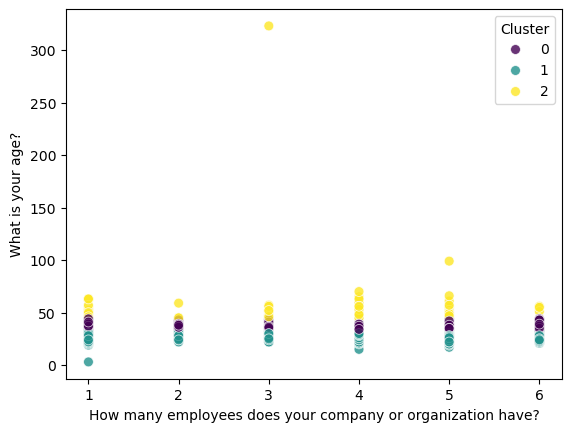

In [10]:
sns.scatterplot(
    data=dataset, 
    x= x, 
    y= y, 
    hue='Cluster', 
    palette='viridis', 
    s=50, 
    alpha=0.8
)

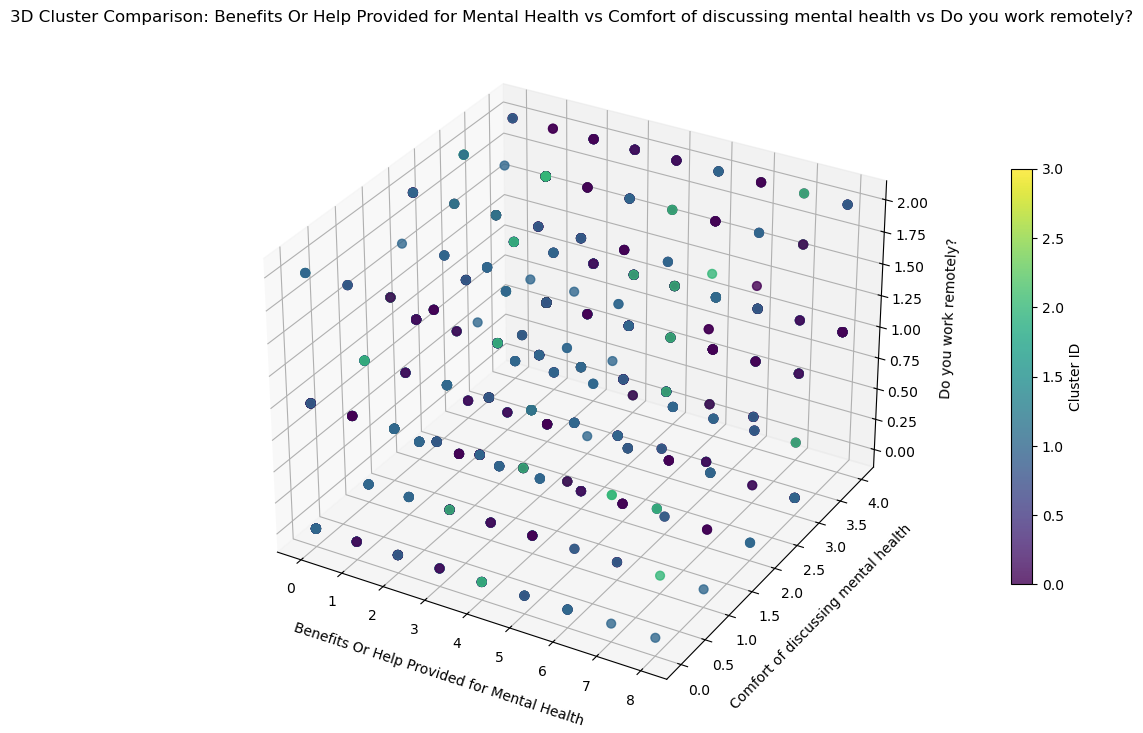

In [26]:
from mpl_toolkits.mplot3d import Axes3D

# Replace with your actual column names
col_x = 'Benefits Or Help Provided for Mental Health'
col_y = 'Comfort of discussing mental health'
col_z = 'Do you work remotely?'

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot using 3 specific columns, colored by Cluster
scatter = ax.scatter(
    dataset[col_x], 
    dataset[col_y], 
    dataset[col_z], 
    c=dataset['Cluster'], 
    cmap='viridis', 
    s=40, 
    alpha=0.8
)

# Label axes based on columns
ax.set_xlabel(col_x, labelpad=10)
ax.set_ylabel(col_y, labelpad=10)
ax.set_zlabel(col_z, labelpad=10)
ax.set_title(f'3D Cluster Comparison: {col_x} vs {col_y} vs {col_z}')

# Add color bar legend
colorbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
colorbar.set_label('Cluster ID')

plt.show()


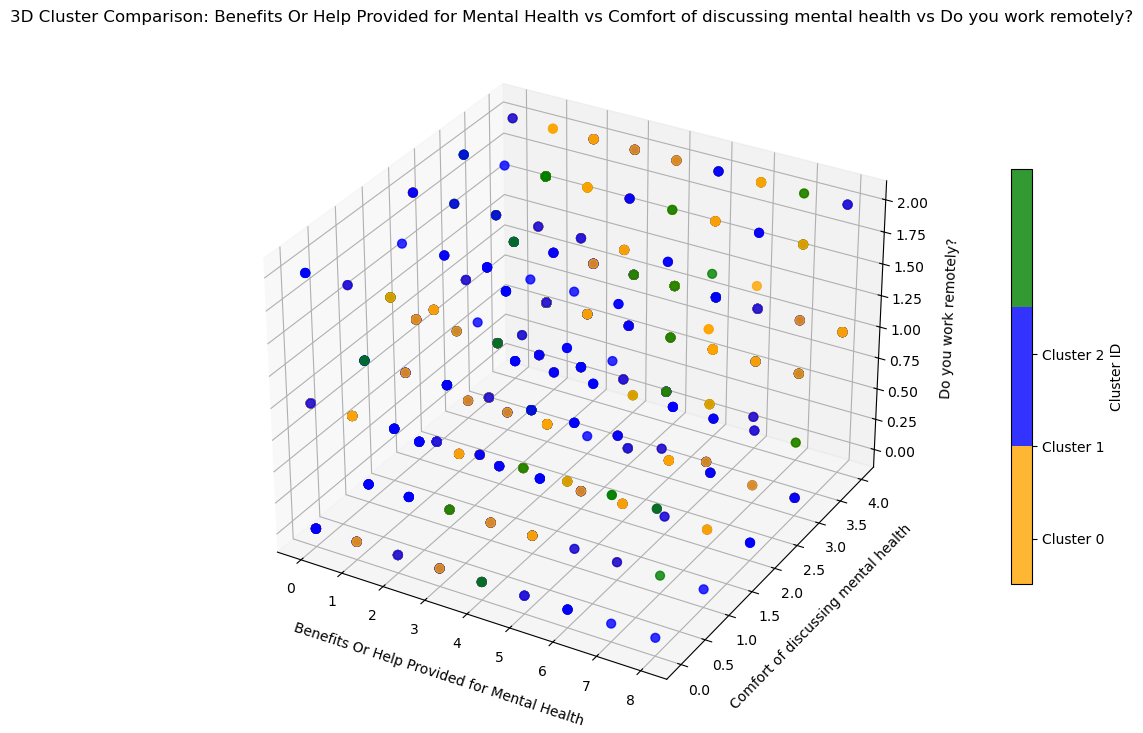

In [28]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from mpl_toolkits.mplot3d import Axes3D

col_x = "Benefits Or Help Provided for Mental Health"
col_y = "Comfort of discussing mental health"
col_z = "Do you work remotely?"

# --- CHOOSE YOUR CUSTOM COLORS HERE ---
# Example: Soft Blue for Cluster 0, Vibrant Coral for Cluster 1, Deep Purple for Cluster 2
my_colors = ["orange", "blue", "green"]
custom_cmap = ListedColormap(my_colors)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection="3d")

# Scatter plot using your custom colormap
scatter = ax.scatter(
    dataset[col_x],
    dataset[col_y],
    dataset[col_z],
    c=dataset["Cluster"],
    cmap=custom_cmap,  # <-- Using your custom colors here
    s=40,
    alpha=0.8,
)

# Label axes based on columns
ax.set_xlabel(col_x, labelpad=10)
ax.set_ylabel(col_y, labelpad=10)
ax.set_zlabel(col_z, labelpad=10)
ax.set_title(f"3D Cluster Comparison: {col_x} vs {col_y} vs {col_z}")

# Add color bar legend
colorbar = fig.colorbar(scatter, ax=ax, pad=0.1, shrink=0.6)
colorbar.set_label("Cluster ID")

# Optional: This forces the colorbar to only show 0, 1, and 2 cleanly
colorbar.set_ticks([0.33, 1.0, 1.66])
colorbar.set_ticklabels(["Cluster 0", "Cluster 1", "Cluster 2"])

plt.show()

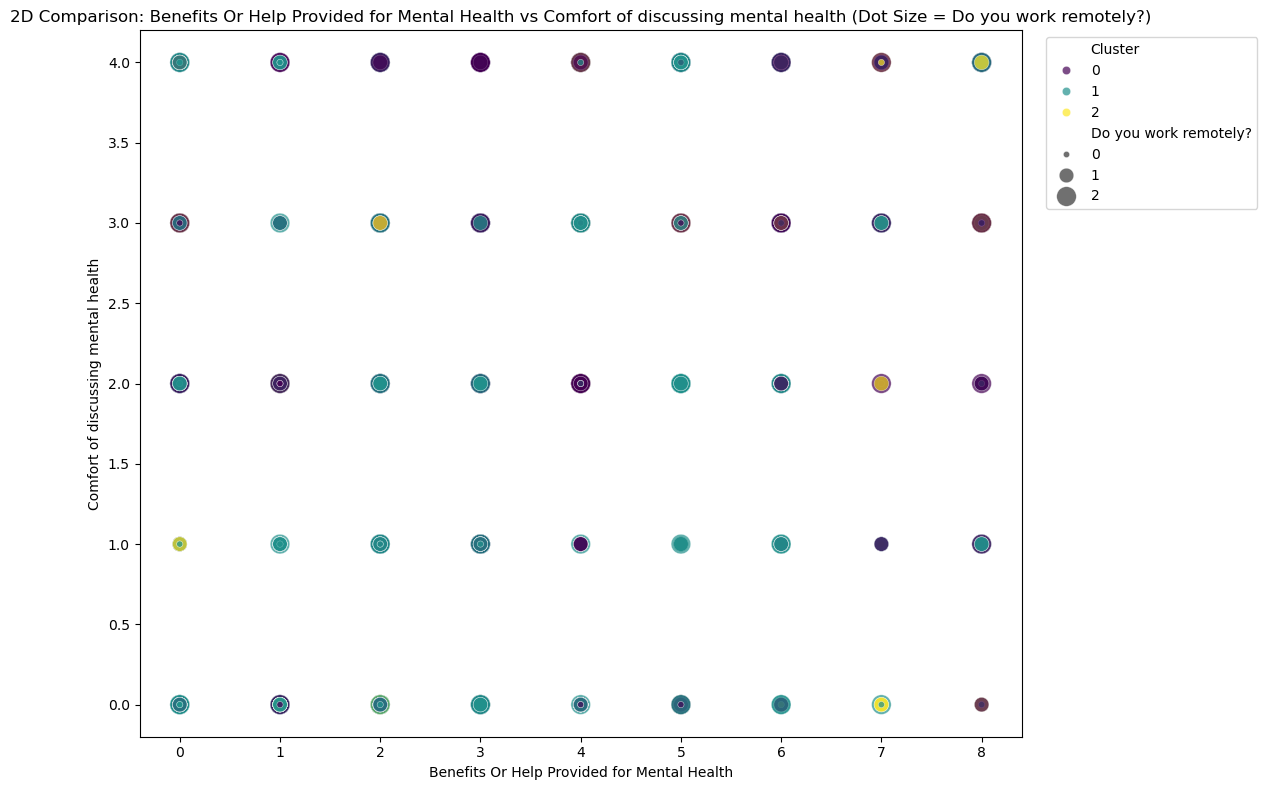

In [12]:

# Replace with your 3 actual column names
col_x = 'Benefits Or Help Provided for Mental Health'  # Goes on X-axis
col_y = 'Comfort of discussing mental health'  # Goes on Y-axis
col_size = 'Do you work remotely?'  # Changes size of the dots

plt.figure(figsize=(12, 8))

# 'hue' handles clusters, 'size' handles the 3rd column
sns.scatterplot(
    data=dataset, 
    x=col_x, 
    y=col_y, 
    hue='Cluster', 
    size=col_size,
    sizes=(20, 200),  # Sets minimum and maximum dot sizes
    palette='viridis', 
    alpha=0.7
)

plt.title(f'2D Comparison: {col_x} vs {col_y} (Dot Size = {col_size})')
plt.xlabel(col_x)
plt.ylabel(col_y)

# Move the legend outside so it doesn't cover your data
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [14]:
# Calculate the average score for each column inside each cluster
profiles = dataset.groupby('Cluster').mean()

# Transpose the table so columns are rows, making it much easier to read
profiles.T


Cluster,0,1,2
How many employees does your company or organization have?,3.280763,3.571014,3.198675
Is your employer primarily a tech company/organization?,0.795494,0.859420,0.781457
Is your primary role within your company related to tech/IT?,1.000000,1.000000,1.000000
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,1.188908,1.153623,1.092715
Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,1.045061,1.011594,1.046358
Do you think that discussing a mental health disorder with previous employers would have negative consequences?,1.088388,1.053623,1.139073
Would you bring up a mental health issue with a potential employer in an interview?,0.485269,0.469565,0.344371
How willing would you be to share with friends and family that you have a mental illness?,1.071057,1.030435,1.039735
Do you currently have a mental health disorder?,1.015598,1.040580,1.046358
Have you been diagnosed with a mental health condition by a medical professional?,0.488735,0.485507,0.615894


In [ ]:
# 1. Fit K-Means (Assuming 4 clusters for this example)
kmeans = KMeans(n_clusters=4, random_state=42)
dataset['Cluster'] = kmeans.fit_predict(dataset)

# 2. Interpret the clusters by calculating the mean of each column
cluster_profiles = dataset.groupby('Cluster').mean()
cluster_profiles.T

Cluster,0,1,2,3
How many employees does your company or organization have?,3.249573,3.603865,3.308057,3.0
Is your employer primarily a tech company/organization?,0.805128,0.859903,0.777251,1.0
Is your primary role within your company related to tech/IT?,1.000000,1.000000,1.000000,1.0
Is your anonymity protected if you choose to take advantage of mental health or substance abuse treatment resources provided by your employer?,1.203419,1.144928,1.094787,1.0
Was your anonymity protected if you chose to take advantage of mental health or substance abuse treatment resources with previous employers?,1.029060,1.012882,1.075829,1.0
Do you think that discussing a mental health disorder with previous employers would have negative consequences?,1.082051,1.053140,1.132701,1.0
Would you bring up a mental health issue with a potential employer in an interview?,0.458120,0.478261,0.426540,1.0
How willing would you be to share with friends and family that you have a mental illness?,1.076923,1.022544,1.042654,1.0
Do you currently have a mental health disorder?,1.003419,1.054750,1.042654,0.0
Have you been diagnosed with a mental health condition by a medical professional?,0.495726,0.478261,0.582938,0.0
